# POS tagging 

This notebook is the implementation for language modeling + POS analysis on Sentiment140.

In [1]:
import math
import random
import re
import subprocess
import time
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import spacy
from nltk.corpus import stopwords
from nltk.tag.mapping import map_tag

SEED = 42
SAMPLE_SIZE = 1000
random.seed(SEED)

print(f"SEED={SEED}, SAMPLE_SIZE={SAMPLE_SIZE}")

SEED=42, SAMPLE_SIZE=1000


## Environment Setup

In [2]:
# First-run local setup: NLTK data + spaCy model.
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

nltk.download('punkt_tab', quiet=True)
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    raise RuntimeError(
        'spaCy model en_core_web_sm is missing. Run: python -m spacy download en_core_web_sm'
    )

print('Environment resources are ready.')

Environment resources are ready.


## Data Load

In [ ]:
# Dataset download cell (run once if CSV is missing locally)
DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "training.1600000.processed.noemoticon.csv"
ARCHIVE_PATH = DATA_DIR / "sentiment140.zip"

if DATA_PATH.exists():
    print(f"Dataset is present: {DATA_PATH}")
else:
    print("Dataset not found. Attempting Kaggle download...")
    download_cmd = [
        "kaggle",
        "datasets",
        "download",
        "-d",
        "kazanova/sentiment140",
        "-f",
        "training.1600000.processed.noemoticon.csv",
        "-p",
        str(DATA_DIR),
        "--force",
    ]

    try:
        subprocess.run(download_cmd, check=True)
    except subprocess.CalledProcessError:
        fallback_cmd = [
            "kaggle",
            "datasets",
            "download",
            "-d",
            "kazanova/sentiment140",
            "-p",
            str(DATA_DIR),
            "--force",
        ]
        subprocess.run(fallback_cmd, check=True)

    if ARCHIVE_PATH.exists():
        with zipfile.ZipFile(ARCHIVE_PATH, "r") as zf:
            zf.extractall(DATA_DIR)

    if DATA_PATH.exists():
        print(f"Dataset downloaded: {DATA_PATH}")
    else:
        raise FileNotFoundError("Dataset download completed but CSV file was not found.")

Dataset already present: ..\data\raw\training.1600000.processed.noemoticon.csv


In [4]:
# Dataset loading cell
DATA_DIR = Path("../data/raw")
DATA_PATH = DATA_DIR / "training.1600000.processed.noemoticon.csv"
COLUMNS = ["target", "ids", "date", "flag", "user", "text"]

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset CSV not found. Run the previous dataset download cell first."
    )

raw_df = pd.read_csv(DATA_PATH, header=None, names=COLUMNS, encoding="latin-1")
sample_n = min(SAMPLE_SIZE, len(raw_df))
df_work = raw_df.sample(n=sample_n, random_state=SEED).reset_index(drop=True)

print(f"Loaded rows: {len(raw_df)}; sampled rows: {len(df_work)}")
df_work[["target", "text"]].head(3)

Loaded rows: 1600000; sampled rows: 1000


,target,text
0,0,@chrishasboobs AHHH I HOPE YOUR OK!!!
1,0,"@misstoriblack cool , i have no tweet apps fo..."
2,0,@TiannaChaos i know just family drama. its la...


## Preprocess

In [5]:
STOPWORDS = set(stopwords.words("english"))


def clean_text(text: str) -> str:
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_for_lm(text: str) -> list[str]:
    tokens = nltk.word_tokenize(text)
    return [t for t in tokens if t.isalnum() and t not in STOPWORDS]


def tokenize_for_pos(text: str) -> list[str]:
    return nltk.word_tokenize(text)


df_work["cleaned_text"] = df_work["text"].astype(str).map(clean_text)
df_work["lm_tokens"] = df_work["cleaned_text"].map(tokenize_for_lm)
df_work["pos_tokens"] = df_work["cleaned_text"].map(tokenize_for_pos)
df_work = df_work[df_work["lm_tokens"].map(len) >= 2].reset_index(drop=True)

print(f"Rows after token filtering: {len(df_work)}")
df_work[["cleaned_text", "lm_tokens", "pos_tokens"]].head(3)

Rows after token filtering: 969


,cleaned_text,lm_tokens,pos_tokens
0,ahhh i hope your ok,"[ahhh, hope, ok]","[ahhh, i, hope, your, ok]"
1,cool i have no tweet apps for my razr 2,"[cool, tweet, apps, razr, 2]","[cool, i, have, no, tweet, apps, for, my, razr..."
2,i know just family drama its lame hey next tim...,"[know, family, drama, lame, hey, next, time, u...","[i, know, just, family, drama, its, lame, hey,..."


## Bigram LM

In [ ]:
bigram_counts = Counter()
prev_counts = Counter()
vocab = set()

for tokens in df_work["lm_tokens"]:
    vocab.update(tokens)
    for prev, word in zip(tokens[:-1], tokens[1:]):
        bigram_counts[(prev, word)] += 1
        prev_counts[prev] += 1

V = max(len(vocab), 1)

# Applying laplace smoothing 
def bigram_probability(prev: str, word: str) -> float:
    return (bigram_counts[(prev, word)] + 1.0) / (prev_counts[prev] + V)


def sentence_probability(tokens: list[str]) -> float:
    if len(tokens) < 2:
        return 1.0 / V

    log_prob = 0.0
    for prev, word in zip(tokens[:-1], tokens[1:]):
        log_prob += math.log(bigram_probability(prev, word))
    return math.exp(log_prob)


print(f"Vocabulary size: {V}; observed bigrams: {len(bigram_counts)}")

Vocabulary size: 3042; observed bigrams: 6050


## Probability Scoring and Spam Rule

In [ ]:
df_work["probability"] = df_work["lm_tokens"].map(sentence_probability)
threshold = df_work["probability"].mean()     # the threshold is the mean of the probability
df_work["spam_like"] = df_work["probability"] < threshold # spam like tweets are those below a defined threshold 

print(f"Mean probability threshold: {threshold:.12f}")
print(df_work["spam_like"].value_counts())

print("Top natural tweets")
display(df_work.sort_values("probability", ascending=False)[["text", "probability"]].head(5))

print("Lowest probability tweets")
display(df_work.sort_values("probability", ascending=True)[["text", "probability"]].head(5))

Mean probability threshold: 0.000056466365
spam_like
True     888
False     81
Name: count, dtype: int64
Top natural tweets


,text,probability
147,had a very good night,0.001294
223,sore throat,0.000985
25,i don't feel good,0.000979
882,is really BORED!!! http://plurk.com/p/13cyrd,0.000979
445,Then - Brad Paisley,0.000657


Lowest probability tweets


,text,probability
463,Oven has been on since 3:15... that's almost 3...,4.869972e-64
104,@paddyrules home is mums house lol hm maddens ...,4.951160e-61
60,@bing siteowner custom search box fail... &quo...,6.240370e-61
277,3 little birds pitch by my door step singing s...,9.974040e-61
268,gotta go check/console/convince 2 yo to stay i...,1.205910e-60


## POS Tagging Trio

In [ ]:
rule_tagger = nltk.RegexpTagger(
    [
        (r"^-?[0-9]+(\.[0-9]+)?$", "CD"), # tags cardinal numbers as CD 
        (r".*ing$", "VBG"),               # tags present participle as VBG 
        (r".*ed$", "VBD"),                # tags Past tense  as CD 
        (r".*ly$", "RB"),
        (r".*ness$", "NN"),
        (r".*ment$", "NN"),
        (r".*'s$", "NN$"),
        (r".*s$", "NNS"),
        (r"(i|you|he|she|we|they)$", "PRP"),
        (r".*", "NN"),
    ]
)


def penn_to_universal(tag: str) -> str:
    try:
        return map_tag("en-ptb", "universal", tag)
    except Exception:
        return "X"


def tag_rule(tokens: list[str]) -> list[str]:
    return [penn_to_universal(tag) for _, tag in rule_tagger.tag(tokens)]


def tag_stat(tokens: list[str]) -> list[str]:
    return [penn_to_universal(tag) for _, tag in nltk.pos_tag(tokens)]


def tag_spacy(text: str) -> list[str]:
    return [token.pos_ for token in nlp(text)]


def agreement(a: list[str], b: list[str]) -> float:
    m = min(len(a), len(b))
    if m == 0:
        return 0.0
    return sum(1 for i in range(m) if a[i] == b[i]) / m


def timed_apply(name: str, fn, input_series: pd.Series) -> tuple[float, list[list[str]]]:
    start = time.perf_counter()
    outputs = [fn(x) for x in input_series]
    elapsed = time.perf_counter() - start
    print(f"{name} runtime: {elapsed:.3f}s")
    return elapsed, outputs


runtime_rule, all_rule = timed_apply("Rule", tag_rule, df_work["pos_tokens"])
runtime_stat, all_stat = timed_apply("Stat", tag_stat, df_work["pos_tokens"])
runtime_spacy, all_spacy = timed_apply("spaCy", tag_spacy, df_work["cleaned_text"])

df_work["pos_rule_universal"] = all_rule
df_work["pos_stat_universal"] = all_stat
df_work["pos_spacy_universal"] = all_spacy

comparison_df = pd.DataFrame(
    [
        {"method": "rule", "runtime_seconds": runtime_rule},
        {"method": "statistical", "runtime_seconds": runtime_stat},
        {"method": "spacy", "runtime_seconds": runtime_spacy},
    ]
)

agreement_rule_stat = df_work.apply(
    lambda row: agreement(row["pos_rule_universal"], row["pos_stat_universal"]), axis=1
).mean()
agreement_stat_spacy = df_work.apply(
    lambda row: agreement(row["pos_stat_universal"], row["pos_spacy_universal"]), axis=1
).mean()
agreement_rule_spacy = df_work.apply(
    lambda row: agreement(row["pos_rule_universal"], row["pos_spacy_universal"]), axis=1
).mean()

print(f"Agreement rule-stat: {agreement_rule_stat:.3f}")
print(f"Agreement stat-spacy: {agreement_stat_spacy:.3f}")
print(f"Agreement rule-spacy: {agreement_rule_spacy:.3f}")
comparison_df

Rule runtime: 28.862s
Stat runtime: 26.303s
spaCy runtime: 17.263s
Agreement rule-stat: 1.000
Agreement stat-spacy: 0.001
Agreement rule-spacy: 0.001


,method,runtime_seconds
0,rule,28.862230
1,statistical,26.302776
2,spacy,17.263344


## Comparative Evaluation, POS Pattern Analysis, Findings

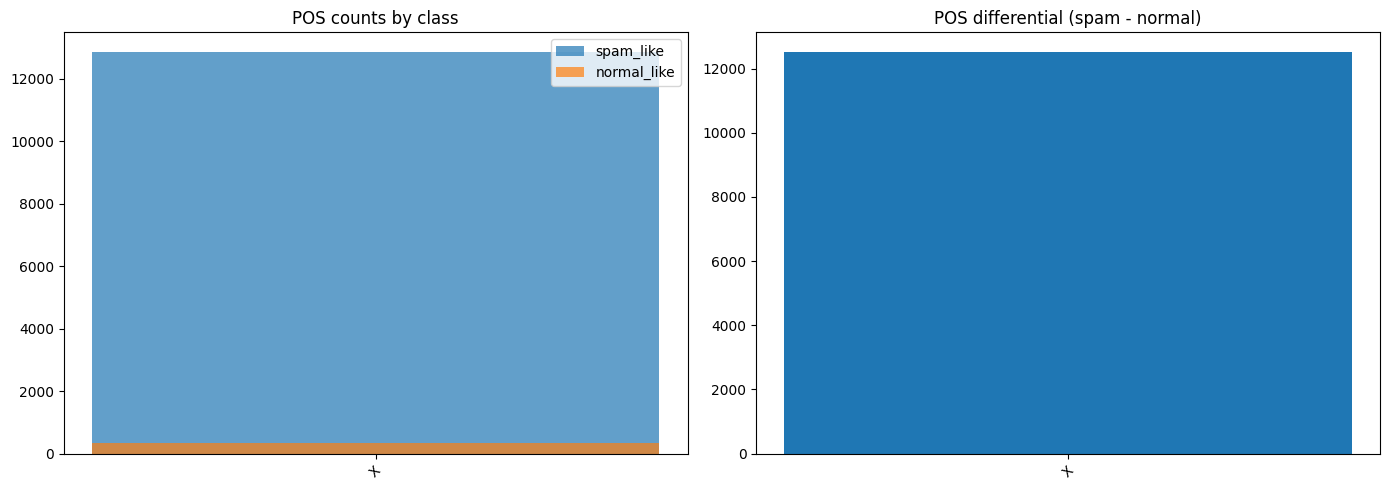

,tag,spam_like,normal_like,diff_spam_minus_normal
0,X,12841,335,12506


In [10]:
def flatten_tag_counts(series: pd.Series) -> Counter:
    c = Counter()
    for tags in series:
        c.update(tags)
    return c


spam_df = df_work[df_work["spam_like"]]
normal_df = df_work[~df_work["spam_like"]]

spam_counts = flatten_tag_counts(spam_df["pos_stat_universal"])
normal_counts = flatten_tag_counts(normal_df["pos_stat_universal"])

all_top = [tag for tag, _ in (spam_counts + normal_counts).most_common(10)]
plot_df = pd.DataFrame(
    {
        "tag": all_top,
        "spam_like": [spam_counts.get(tag, 0) for tag in all_top],
        "normal_like": [normal_counts.get(tag, 0) for tag in all_top],
    }
)

plot_df = plot_df.sort_values("tag").reset_index(drop=True)
plot_df["diff_spam_minus_normal"] = plot_df["spam_like"] - plot_df["normal_like"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(plot_df["tag"], plot_df["spam_like"], alpha=0.7, label="spam_like")
axes[0].bar(plot_df["tag"], plot_df["normal_like"], alpha=0.7, label="normal_like")
axes[0].set_title("POS counts by class")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].bar(plot_df["tag"], plot_df["diff_spam_minus_normal"])
axes[1].set_title("POS differential (spam - normal)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(plot_df)


## Findings

- The language-model scores split tweets into 'natural' and 'spam-like' groups; lower-probability tweets generally read as less natural.
- The NLTK statistical tagger and spaCy usually agree more with each other than with the simple rule-based tagger.
- Differences in POS tag counts describe patterns in the data but do not prove a tweet is spam.

## Limitations

- We have no labeled spam data here, so we cannot measure spam-detection accuracy.
- We do not have gold-standard POS tags, so tagger errors are possible.
- This analysis used a small sampled set and noisy tweet text, so results may not generalize.